In [ ]:
# !pip install ultralytics

In [4]:
import ultralytics

ultralytics.checks()

Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.5/235.7 GB disk)


In [8]:
from ultralytics import YOLO

model = YOLO('yolov8n-pose.pt')
results = model('./bus.jpg', save=True)


image 1/1 /content/bus.jpg: 640x480 4 persons, 7.4ms
Speed: 2.1ms preprocess, 7.4ms inference, 6.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/pose/predict3


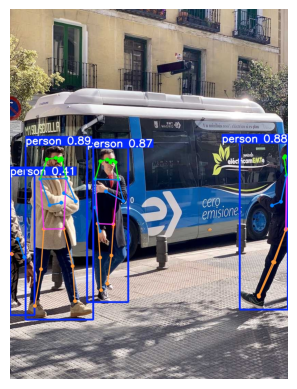

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('./runs/pose/predict3/bus.jpg')

plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
model = YOLO('yolov8n-pose.yaml')
results = model.train(data='coco8-pose.yaml', epochs=100, imgsz=640)

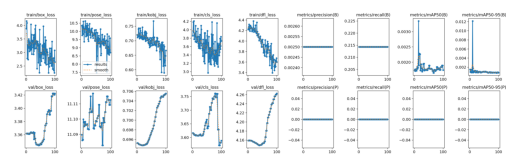

In [11]:
img = mpimg.imread('./runs/pose/train/results.png')

plt.imshow(img)
plt.axis('off')
plt.show()

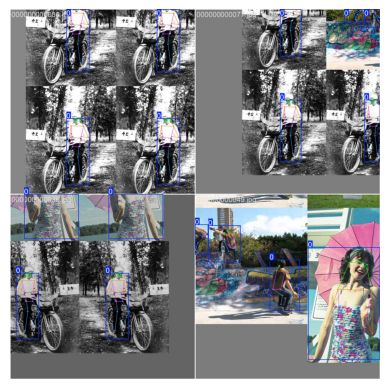

In [15]:
img = mpimg.imread('./runs/pose/train/train_batch0.jpg')

plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
model = YOLO('yolov8n-pose.pt')
model(source='people_walk.mp4',save=True, imgsz=640)

In [ ]:
import cv2
import math
import numpy as np

colorMap = {
    'leftNeck' : (255,0,0),
    'rightNeck' : (0,0,255),
    'neck' : (0,0,255),
    'leftUpperArm' : (205,90,106),
    'rightUpperArm' : (147,20,255),
    'leftLowerArm' : (129,61,72),
    'rightLowerArm' : (180,105,255),
    'leftBody':(221,160,221),
    'rightBody':(238,130,238),
    'pelvis':(50,205,50),
    'leftUpperLeg':(255,0,255),
    'rightUpperLeg':(128,0,0),
    'leftLowerLeg' : (193,182,255),
    'rightLowerLeg' : (139,61,72)
}

partDict = {
    'leftNeck':(3,5),
    'rightNeck' : (4,6),
    'neck' : (5, 6),
    'leftUpperArm' : (5,7),
    'rightUpperArm' : (6,8),
    'leftLowerArm' : (7,9),
    'rightLowerArm' : (8,10),
    'leftBody' :(5,11),
    'rightBody':(6,12),
    'pelvis':(11,12),
    'leftUpperLeg':(11,13),
    'rightUpperLeg':(12,14),
    'leftLowerLeg':(13,15),
    'rightLowerLeg':(14,16)
}

In [ ]:
def distance(x1, y1, x2, y2):
    result = math.sqrt(math.pow(x1 - x2, 2) + math.pow(y1 - y2, 2))
    return int(result)

def drawLine(frame, name, org, dst):
    if (org.any() == 0 or dst.any() == 0):
        return frame
    frame = cv2.line(frame, org, dst, colorMap[name], 5)
    return frame

In [ ]:
model = YOLO('yolov8n-pose.pt')
cap = cv2.VideoCapture('sample.mp4')

while True:
    ret, frame = cap.read()

    if not ret:
        print('Video frame is empty or video processiong has been successfully completed')
        break

    frame = cv2.resize(frame, (1280,720))
    results = model(frame, stream=True)

    for r in results:
        keypoints = r.keypoints

        for ks  in keypoints:
            k = np.array(ks.xy[0], dtype=int)

            try :
                cv2.circle(frame,
                           k[0],
                           distance(k[0][0], k[0][1], k[3][0], k[3][1]),
                           (255,255,255),
                           5)

                for idx, (name, (org, dst)) in enumerate(partDict.items()):

                    frame = cv2.putText(frame,
                                        name + str(k[org]) + str(k[dst]),
                                        (50, idx*30),
                                        cv2.FONT_HERSHEY_COMPLEX,
                                        1,
                                        (0,255,255),
                                        2)

                    frame = drawLine(frame, name, k[org], k[dst])
            except Exception as e :
                print(e)
    cv2.imshow('result preview', frame)
    if cv2.waitKey(1) == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()